### Импорты:

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

### Задача 1:

#### описание таблицы:
* **Country** / Страна;
* **happiness_score** / Индекс счастья (итоговый балл);
* **gdp_per_capita** / ВВП на душу населения (вклад экономики);
* **family** / Семейные связи и поддержка (вклад семьи);
* **health** / Здоровье и ожидаемая продолжительность жизни;
* **freedom** / Свобода жизненного выбора;
* **generosity** / Щедрость (уровень благотворительности);
* **government_trust** / Доверие к правительству (уровень отсутствия коррупции по данным WHR);
* **dystopia_residual** / Остаток дистопии (базовое сравнение с самой несчастной страной);
* **continent** / Континент / Материк.
* **Year** / Год проведения исследования
* **social_support** / Социальная поддержка
* **cpi_score** / Индекс восприятия коррупции Transparency International (чем выше значение, тем *менее* коррумпирована страна)

#### чтение и описание датасета:

In [103]:
#чтение csv:
df = pd.read_csv('happines_corruption.csv')
df.head()

,Country,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,continent,Year,social_support,cpi_score
0,Norway,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,Europe,2015,0.0,88
1,Denmark,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,Europe,2015,0.0,91
2,Iceland,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,Europe,2015,0.0,79
3,Switzerland,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,Europe,2015,0.0,86
4,Finland,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,Europe,2015,0.0,90


In [104]:
# проверка пропусков:
df.isnull().sum()

Country              0
happiness_score      0
gdp_per_capita       0
family               0
health               0
freedom              0
generosity           0
government_trust     0
dystopia_residual    0
continent            0
Year                 0
social_support       0
cpi_score            0
dtype: int64

In [105]:
# проверка дубликатов:
df.duplicated().sum()

np.int64(0)

In [106]:
# общая информация:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            792 non-null    object 
 1   happiness_score    792 non-null    float64
 2   gdp_per_capita     792 non-null    float64
 3   family             792 non-null    float64
 4   health             792 non-null    float64
 5   freedom            792 non-null    float64
 6   generosity         792 non-null    float64
 7   government_trust   792 non-null    float64
 8   dystopia_residual  792 non-null    float64
 9   continent          792 non-null    object 
 10  Year               792 non-null    int64  
 11  social_support     792 non-null    float64
 12  cpi_score          792 non-null    int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 80.6+ KB


In [107]:
# описательная стата:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
happiness_score,792.0,5.473310,1.124726,2.5669,4.590750,5.485500,6.300500,7.808700
gdp_per_capita,792.0,0.929217,0.385774,0.0000,0.644242,0.994544,1.228677,2.096000
family,792.0,0.504998,0.552736,0.0000,0.000000,0.000000,1.040410,1.610574
health,792.0,0.648691,0.232261,0.0000,0.510070,0.685397,0.815641,1.141000
freedom,792.0,0.427016,0.148003,0.0000,0.325433,0.439621,0.546280,0.724000
generosity,792.0,0.212440,0.121660,0.0000,0.125784,0.197000,0.273250,0.838075
government_trust,792.0,0.125720,0.109032,0.0000,0.052862,0.089000,0.154250,0.551910
dystopia_residual,792.0,1.379277,1.075276,0.0000,0.000000,1.731948,2.236894,3.602140
Year,792.0,2017.500000,1.708904,2015.0000,2016.000000,2017.500000,2019.000000,2020.000000
social_support,792.0,0.609302,0.640754,0.0000,0.000000,0.176214,1.268250,1.644000


In [108]:
# для себя смотрю там самых коррумпированных стран по 2020 году
# # фильтруем год:
# df_2020 = df_hc[df_hc['Year'] == 2020]
# # Сортировка по возрастанию (от самых коррумпированных с низким cpi_score к честным)
# df_2020.sort_values(by='cpi_score').head(35)

# второй вариант:
df[df['Year'] == 2020].sort_values(by='cpi_score').head(10)

,Country,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,continent,Year,social_support,cpi_score
786,Yemen,3.5274,0.392702,0.0,0.415000,0.243721,0.094689,0.087352,1.116473,Asia,2020,1.177477,15
748,Venezuela,5.0532,0.770239,0.0,0.767026,0.271717,0.087179,0.063625,1.744841,South America,2020,1.348547,15
733,Libya,5.4888,1.021914,0.0,0.615627,0.451354,0.142758,0.172258,1.888563,Africa,2020,1.196284,17
783,Haiti,3.7208,0.284734,0.0,0.374367,0.169298,0.463910,0.161936,1.619917,South America,2020,0.646671,18
781,Burundi,3.7753,0.000000,0.0,0.295213,0.275399,0.187402,0.212187,2.401507,Africa,2020,0.403575,19
744,Turkmenistan,5.1191,1.008964,0.0,0.612448,0.515237,0.323129,0.033504,1.115337,Asia,2020,1.510477,19
791,Afghanistan,2.5669,0.300706,0.0,0.266052,0.000000,0.135235,0.001226,1.507236,Asia,2020,0.356434,19
754,Cambodia,4.8484,0.544635,0.0,0.587904,0.674940,0.233342,0.072838,1.663300,Asia,2020,1.071426,21
771,Chad,4.4227,0.302287,0.0,0.108744,0.228602,0.210805,0.085755,2.747427,Africa,2020,0.739118,21
758,Iraq,4.7848,0.982019,0.0,0.529351,0.283588,0.153002,0.073165,1.752174,Asia,2020,1.011467,21


<div class="alert alert-info">
<b>Проверка гипотез и выявление связей:</b>

- **Гипотезы:**
1. Существует ли прямая положительная связь между уровнем ВВП на душу населения (gdp_per_capita) и уровнем социальной поддержки (social_support_total)?
2. Чем ниже уровень коррупции (cpi_score), тем выше уровень счастья (happiness_score)?

- **Связи**
1. Проверить связь между уровнем ВВП на душу населения (gdp_per_capita) и уровнем социальной поддержки (social_support_total).
2. wa

</div>

#### проверка гипотезы №1:
Существует ли прямая положительная связь между уровнем ВВП на душу населения (gdp_per_capita) и уровнем социальной поддержки (social_support_total)?

In [109]:
# сперва проверим одинаковы ли столбцы 'family' и 'social_support'
df[df['Country'] == 'United States'][['Year', 'family', 'social_support']]

,Year,family,social_support
13,2015,1.419921,0.000000
146,2016,1.247110,0.000000
282,2017,0.000000,1.457000
413,2018,0.000000,1.471000
540,2019,1.047820,0.000000
677,2020,0.000000,1.404787


In [110]:
df[df['Country'] == 'Russia'][['Year', 'family', 'social_support']]

,Year,family,social_support
44,2015,1.469282,0.000000
188,2016,1.236170,0.000000
325,2017,0.000000,1.452000
447,2018,0.000000,1.479000
576,2019,1.052610,0.000000
728,2020,0.000000,1.378644


как показано выше, в годы, когда в столбце 'family' были значения, столбец 'social_support' был по нулям. Тк я не знаю всей методики и у меня нет документации.
Предположим, что это одинаковые столбцы, но в разные годы во премя проведения опросов были названы по разному. Поэтому примедем эти два столбца к одной колонке с названием 'social_support_total'

In [111]:
# мы объединили две колонки в одну результирующую
#
# np.where(УСЛОВИЕ, ЧТО_ВЗЯТЬ_ЕСЛИ_ИСТИНА, ЧТО_ВЗЯТЬ_ЕСЛИ_ЛОЖЬ)

# создаем копию:
df_hc = df.copy()


df_hc['social_support_total'] = np.where(
    df_hc['social_support'] != 0,
    df_hc['social_support'],
    df_hc['family']
)
df_hc

,Country,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,continent,Year,social_support,cpi_score,social_support_total
0,Norway,7.5370,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,Europe,2015,0.000000,88,1.533524
1,Denmark,7.5220,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,Europe,2015,0.000000,91,1.551122
2,Iceland,7.5040,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,Europe,2015,0.000000,79,1.610574
3,Switzerland,7.4940,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,Europe,2015,0.000000,86,1.516912
4,Finland,7.4690,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,Europe,2015,0.000000,90,1.540247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,Botswana,3.4789,0.997549,0.000000,0.494102,0.509089,0.033407,0.101786,0.257241,Africa,2020,1.085695,60,1.085695
788,Tanzania,3.4762,0.457163,0.000000,0.442678,0.509343,0.271541,0.203881,0.718963,Africa,2020,0.872675,38,0.872675
789,Rwanda,3.3123,0.343243,0.000000,0.572383,0.604088,0.235705,0.485542,0.548445,Africa,2020,0.522876,54,0.522876
790,Zimbabwe,3.2992,0.425564,0.000000,0.375038,0.377405,0.151349,0.080929,0.841031,Africa,2020,1.047835,24,1.047835


Проверяем данные на нормальность:
тк у нас дата френйм от 30 до 1000, воспользуемся тестом Шапиро

In [112]:
# проверка на нормальность индексов счастья:
stat_gdp, p_value_gdp = stats.shapiro(df_hc['gdp_per_capita'])

# проверка на нормальность социальной поддержки:
stat_soc, p_value_soc = stats.shapiro(df_hc['social_support_total'])

# Выводим результаты проверки теста нормальности данных:
print(f'p-value_hap = {p_value_gdp:.2e}')
print(f'p-value_soc = {p_value_soc:.2e}')

p-value_hap = 8.27e-12
p-value_soc = 3.48e-15


Вероятно данные распределены НЕ нормально, тк p-value меньше 0,05 отвергаем h0 гипотезу о нормальности данных. Для числовых данных воспользуемся воспользуемся тестом Спирмена

In [113]:
rho_soc, p_value_soc = stats.spearmanr(df_hc['gdp_per_capita'], df_hc['social_support_total'])

print(f'Гипотеза 1 (ВВП vs Соцподдержка): rho = {rho_soc:.3f}, p-value = {p_value_soc:.2e}')

Гипотеза 1 (ВВП vs Соцподдержка): rho = 0.604, p-value = 4.74e-80


Поскольку p_value = 4.74 * 10^-80 < 0.05, нулевая гипотеза об отсутствии связи отвергается. Результаты теста Спирмена rho = 0.604 подтверждают наличие статистически значимой положительной связи умеренной силы между ВВП на душу населения и уровнем социальной поддержки.
Проверим графически нашу информацию:

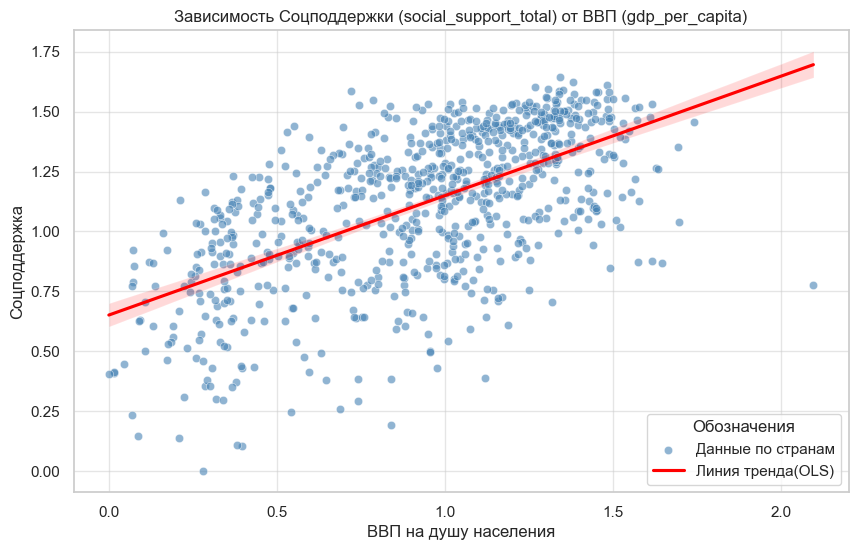

In [114]:
# 1. Устанавливаем белый стиль оформления
sns.set_theme(style='whitegrid')

# 2. Строим график и указываем label для легенды
plt.figure(figsize=(10, 6))

# 3. Строим точки
sns.scatterplot(
    data=df_hc,
    x='gdp_per_capita',
    y='social_support_total',
    color='steelblue',
    alpha=0.6,
    label='Данные по странам'
)

# 4. Накладываем линию тренда
sns.regplot(
    data=df_hc,
    x='gdp_per_capita',
    y='social_support_total',
    scatter=False, # не дублируем точки
    line_kws={'color': 'red'},
    label='Линия тренда(OLS)'
)


plt.title('Зависимость Соцподдержки (social_support_total) от ВВП (gdp_per_capita)')
plt.xlabel('ВВП на душу населения')
plt.ylabel('Соцподдержка')

# 3. Отображаем легенду
plt.legend(title='Обозначения', loc='lower right')

plt.show()

In [115]:

fig = px.scatter(
    data_frame=df_hc,
    x='gdp_per_capita',
    y='social_support_total',
    hover_name='Country', # что показывать при наведении
    trendline='ols',                        # добавляет линию тренда
    title='Зависимость Соцподдержки (social_support_total) от ВВП (gdp_per_capita)'
)

fig.show()

Визуальный анализ диаграммы рассеяния подтверждает выводы теста Спирмена. На графике наблюдается выраженная восходящая тенденция. При этом характер разброса данных меняется: для стран с низким ВВП ($<0.5$) характерна высокая вариативность социальной поддержки, тогда как для развитых экономик ($>1.0$) значения концентрируются в верхнем диапазоне ($1.25$–$1.60$), что свидетельствует об устойчиво высоком уровне социальной поддержки в странах с высоким доходом

#### Проверка гипотезы № 2:
Чем ниже уровень коррупции (cpi_score), тем выше уровень счастья (happiness_score)?

In [116]:
# Также стоит учитывать, что у нас индекс коррупции увеличивается чем больше значение, тем страна менее коррумпирована (отсутствие коррупции = высокий балл)

stat_hap, p_value_hap = stats.shapiro(df_hc['happiness_score'])

stat_cpi, p_value_cpi = stats.shapiro(df_hc['cpi_score'])

print(f'p-value_hap = {p_value_hap:.2e}')

print(f'p-value_cpi = {p_value_cpi:.2e}')

p-value_hap = 2.56e-07
p-value_cpi = 1.48e-20


Вероятно данные распределены не нормально, используем тест Спирмана

In [117]:
'''
Гипотеза h0: "Статистически значимая связь между индексом восприятия коррупции (cpi_score) и уровнем счастья (happiness_score) отсутствует (rho = 0)
Гипотеза h1: :Между индексом восприятия коррупции (cpi_score) и уровнем счастья (happiness_score) существует статистически значимая положительная связь (rho != 0)
'''
rho_cpi, p_value_cpi = stats.spearmanr(df_hc['cpi_score'], df_hc['happiness_score'])

print(f'сила связи: rho_cpi = {rho_cpi:.2f}, критерий проверки гипотезы: p-value_cpi = {p_value_cpi:.2e}')

сила связи: rho_cpi = 0.62, критерий проверки гипотезы: p-value_cpi = 5.35e-86


Так как $p\text{-value} = 5.35 \times 10^{-86} < 0.05$, нулевая гипотеза об отсутствии связи отвергается. Результаты теста Спирмена ($\rho = 0.62$) подтверждают наличие статистически значимой заметной положительной связи: в странах с более высоким баллом CPI (что соответствует более низкому уровню коррупции) наблюдается более высокий уровень счастья населения

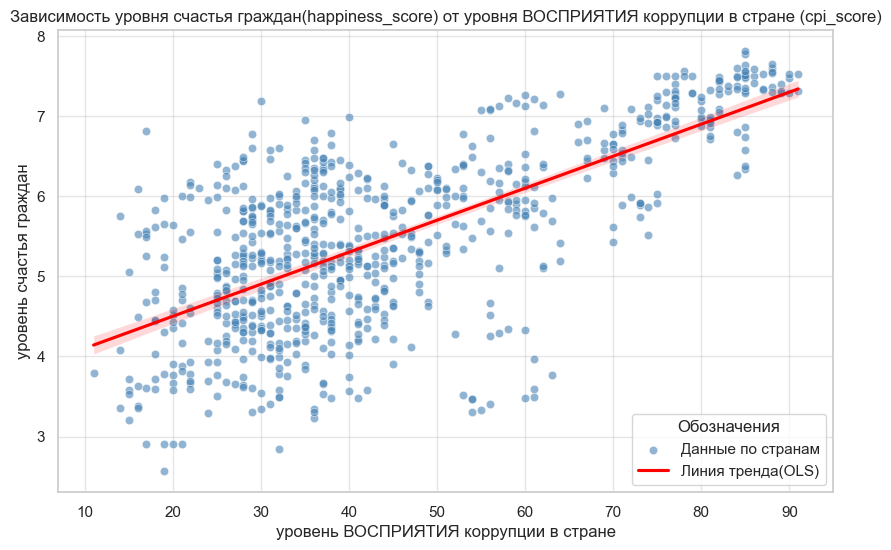

In [118]:
# 1. Устанавливаем белый стиль оформления
sns.set_theme(style='whitegrid')

# 2. Строим график и указываем label для легенды
plt.figure(figsize=(10, 6))

# 3. Строим точки
sns.scatterplot(
    data=df_hc,
    x='cpi_score',
    y='happiness_score',
    color='steelblue',
    alpha=0.6,
    label='Данные по странам'
)

# 4. Накладываем линию тренда
sns.regplot(
    data=df_hc,
    x='cpi_score',
    y='happiness_score',
    scatter=False, # не дублируем точки
    line_kws={'color': 'red'},
    label='Линия тренда(OLS)'
)


plt.title('Зависимость уровня счастья граждан(happiness_score) от уровня ВОСПРИЯТИЯ коррупции в стране (cpi_score)')
plt.xlabel('уровень ВОСПРИЯТИЯ коррупции в стране')
plt.ylabel('уровень счастья граждан')

# 3. Отображаем легенду
plt.legend(title='Обозначения', loc='lower right')

plt.show()

In [119]:

fig = px.scatter(
    data_frame=df_hc,
    x='cpi_score',
    y='happiness_score',
    hover_name='Country', # что показывать при наведении
    trendline='ols',                        # добавляет линию тренда
    title='Зависимость уровня счастья граждан(happiness_score) от уровня коррупции в стране (cpi_score)'
)

fig.show()

<div class="alert alert-info">
<b>Выводы:</b>

- Графический анализ показывает, что положительная связь проявляется нелинейно на разных участках распределения:
  (Напоминание: по шкале CPI чем выше значение `cpi_score`, тем ниже уровень восприятия коррупции, поэтому ожидается прямая зависимость с уровнем счастья).

  1. <b>Участок № 1 (CPI от 10 до 50):</b> характеризуется высокой дисперсией и хаотичным распределением точек. На этом отрезке нельзя утвердительно говорить о наличии выраженной положительной связи.
  2. <b>Участок № 2 (CPI от 50-60 и выше):</b> демонстрирует четкую наглядную тенденцию — уровень счастья граждан растет параллельно со снижением уровня восприятия коррупции, а разброс значений существенно сокращается.

- Высокая дисперсия на первом участке и особенности распределения обусловлены следующими факторами:

<b>1. Ограничения данных и сбора:</b>
- <i>Методология сбора:</i> данные о счастье и социальной поддержке опираются на социологические опросы (например, Gallup World Poll). В развивающихся странах или зонах конфликтов (например, Афганистан) качество выборки, а также искренность ответов респондентов могут существенно уступать стандартам развитых стран.
- <i>Природа индекса CPI:</i> показатель отражает именно восприятие коррупции, а не ее абсолютный объем. Информационная политика и уровень свободы СМИ в отдельных регионах могут искажать итоговую оценку экспертов.

<b>2. Методологическое ограничение индекса CPI:</b>
- Показатель CPI отражает восприятие коррупции, очерченное западными институциональными рамками. В нем четко разделяются бытовая/криминальная коррупция и легальный лоббизм (продвижение интересов бизнеса). Культурные и правовые различия в восприятии лоббизма в разных странах (например, в РФ и странах ЕС/ФРГ) могут создавать смещение в экспертных оценках. Из-за этого индекс фиксирует скорее прозрачность институциональных процедур по западным стандартам, а не полное отсутствие влияния капитала на политические решения.
</div>

#### строим матрицу корреляций числовых показателей:

In [120]:
# Выбираем только числовые колонки (если нужно) и считаем корреляцию Спирмена
corr_matrix = df_hc.corr(method='spearman', numeric_only=True)

# Можно посмотреть на саму таблицу
corr_matrix

,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,Year,social_support,cpi_score,social_support_total
happiness_score,1.000000,0.796952,0.139737,0.765699,0.549513,0.138579,0.351135,0.233622,0.025435,0.239110,0.622027,0.668314
gdp_per_capita,0.796952,1.000000,0.215922,0.770263,0.360422,-0.002301,0.287957,0.064533,-0.042062,0.142498,0.735174,0.604429
family,0.139737,0.215922,1.000000,-0.074117,0.006478,0.227875,0.102359,0.557576,-0.591407,-0.855444,0.113448,-0.073002
health,0.765699,0.770263,-0.074117,1.000000,0.415357,-0.019394,0.210789,-0.045528,0.070242,0.387623,0.685520,0.621764
freedom,0.549513,0.360422,0.006478,0.415357,1.000000,0.339178,0.441906,0.003327,0.059778,0.236287,0.422193,0.464637
generosity,0.138579,-0.002301,0.227875,-0.019394,0.339178,1.000000,0.234489,0.160056,-0.104285,-0.182996,0.065831,-0.009977
government_trust,0.351135,0.287957,0.102359,0.210789,0.441906,0.234489,1.000000,0.137310,0.022828,-0.010907,0.333023,0.124251
dystopia_residual,0.233622,0.064533,0.557576,-0.045528,0.003327,0.160056,0.137310,1.000000,0.089763,-0.594248,0.042921,-0.270343
Year,0.025435,-0.042062,-0.591407,0.070242,0.059778,-0.104285,0.022828,0.089763,1.000000,0.426961,0.005542,-0.114708
social_support,0.239110,0.142498,-0.855444,0.387623,0.236287,-0.182996,-0.010907,-0.594248,0.426961,1.000000,0.147637,0.571649


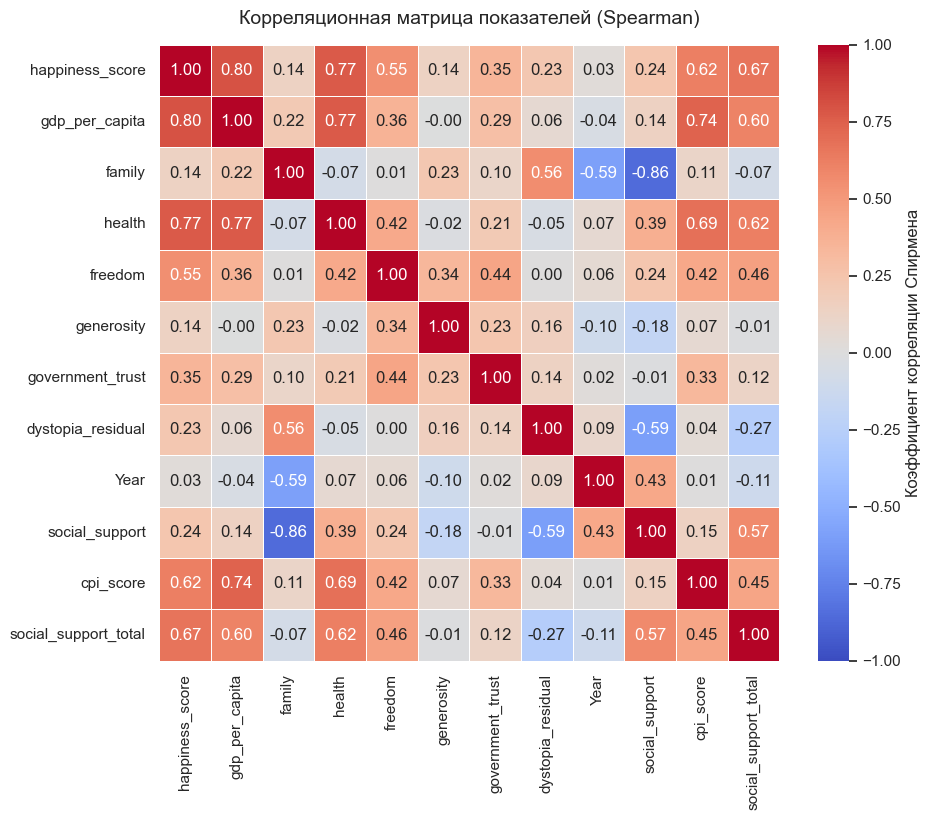

In [121]:
sns.set_theme(style='white')

# 1. Задаем размер (квадратный холст идеально подходит для матриц)
plt.figure(figsize=(10, 8))

# 2. Строим тепловую карту
sns.heatmap(
    corr_matrix,
    annot=True,          # Выводить числовые значения внутри ячеек
    fmt='.2f',           # Округление чисел до 2 знаков после запятой
    cmap='coolwarm',     # Цветовая палитра (синий = отрицательная, красный = положительная)
    vmin=-1, vmax=1,     # Границы шкалы от -1 до 1
    linewidths=0.5,      # Сетка между ячейками
    cbar_kws={'label': 'Коэффициент корреляции Спирмена'}
)

plt.title('Корреляционная матрица показателей (Spearman)', fontsize=14, pad=15)
plt.show()

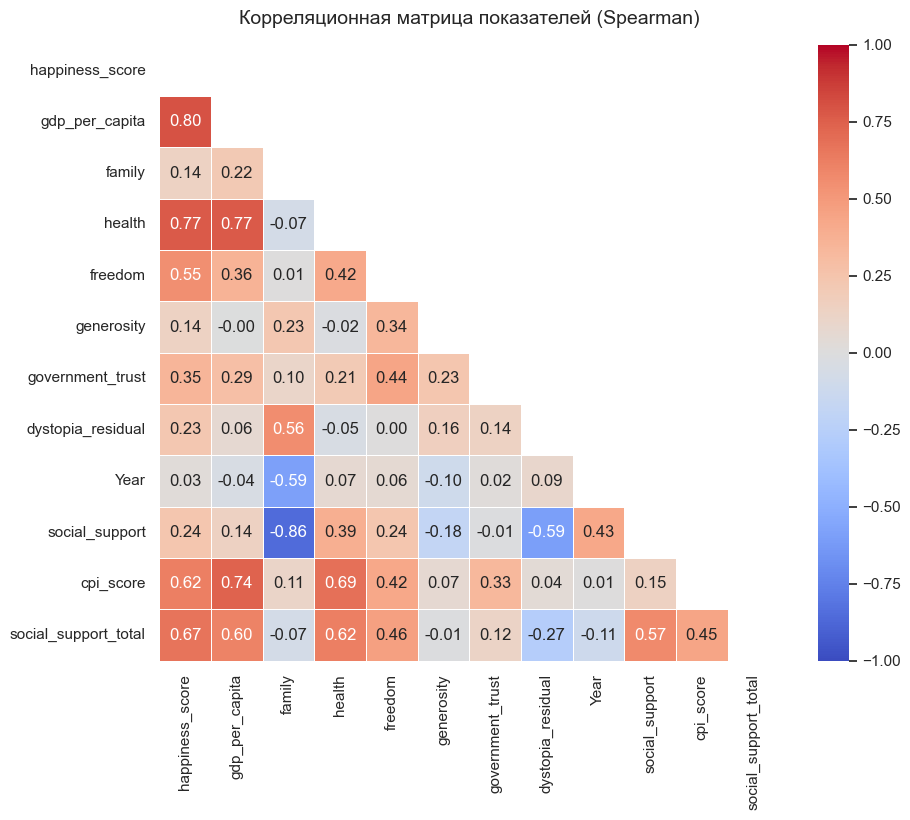

In [126]:
# 1. Считаем матрицу
corr_matrix = df_hc.corr(method='spearman', numeric_only=True)

# 2. Генерируем маску строго по размерам corr_matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# 3. Обязательно передаем аргумент mask=mask!
sns.heatmap(
    corr_matrix,
    mask=mask,           # -- Вот этот параметр срезает верхний дублирующийся треугольник
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Корреляционная матрица показателей (Spearman)', fontsize=14, pad=15)
plt.show()

### Задача 2:

#### Описание таблицы:

In [128]:
df2 = pd.read_csv('gas_sales_data.csv')
df2

,Year,Month,Temperature,Gangwondo,Seoul,Gyeonggido,Incheon,Gyeongsangnamdo,Gyeongsangbukdo,Gwangju,...,Daejeon,Busan,Sejong,Ulsan,Jeollanamdo,Jeollabukdo,Jeju,Chungcheongnamdo,Chungcheongbukdo,Sum
0,2000,1,-1.20,16219,662424,363014,139454,42129,55362,39465,...,52992,85787,0,69241,22508,34507,0,20158,27838,1717175
1,2000,2,-0.99,16280,689177,375937,145834,42604,52863,40674,...,53950,87282,0,70910,22310,33784,0,23492,27175,1766341
2,2000,3,6.64,14105,566528,323145,121324,35990,47282,34610,...,41898,74476,0,63627,18033,29315,0,21156,22904,1490537
3,2000,4,12.11,10364,396231,237437,91421,28698,40393,25898,...,28618,58316,0,47106,15920,19783,0,17447,16818,1096964
4,2000,5,17.59,6843,262940,169495,67239,21073,35083,18426,...,17503,45915,0,43749,13808,14375,0,14508,12299,790248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2020,8,27.00,19076,163032,255222,70646,60523,84646,27561,...,31906,70508,5599,94251,49039,43885,1506,70181,49460,1142099
248,2020,9,21.40,18822,147556,243817,72542,65264,88652,28120,...,30307,70849,6069,101433,54253,48190,1179,86971,53589,1160655
249,2020,10,14.90,25946,213556,339823,78654,75071,103757,39428,...,42001,85283,10268,119332,60416,61328,1414,109095,61315,1471242
250,2020,11,9.00,35632,375289,497221,115663,101609,135432,58120,...,69624,122943,12087,147792,68793,82360,2161,142556,82499,2116835


In [131]:
df_gas = df2[['Temperature', 'Sum']]
df_gas

,Temperature,Sum
0,-1.20,1717175
1,-0.99,1766341
2,6.64,1490537
3,12.11,1096964
4,17.59,790248
...,...,...
247,27.00,1142099
248,21.40,1160655
249,14.90,1471242
250,9.00,2116835


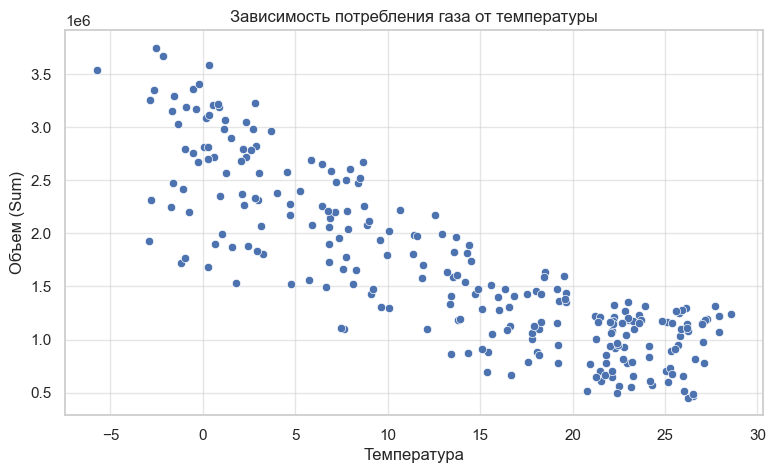

In [136]:
# строим диаграмму рассеивания:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_gas,
    x='Temperature',
    y='Sum'
)

plt.title('Зависимость потребления газа от температуры')
plt.xlabel('Температура')
plt.ylabel('Объем (Sum)')
plt.grid(True)
plt.show()

обучаем модель 80/20

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_gas[['Temperature']]
y = df_gas['Sum']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-71214.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.622e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


делаем предсказание по обученной модели

In [143]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Делаем предсказания на тестовой выборке
y_pred = model.predict(X_test)

# 2. Считаем метрики
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R² score: {r2:.3f}')
print(f'MAE: {mae:.3f}')

R² score: 0.729
MAE: 329876.503


график остатков:

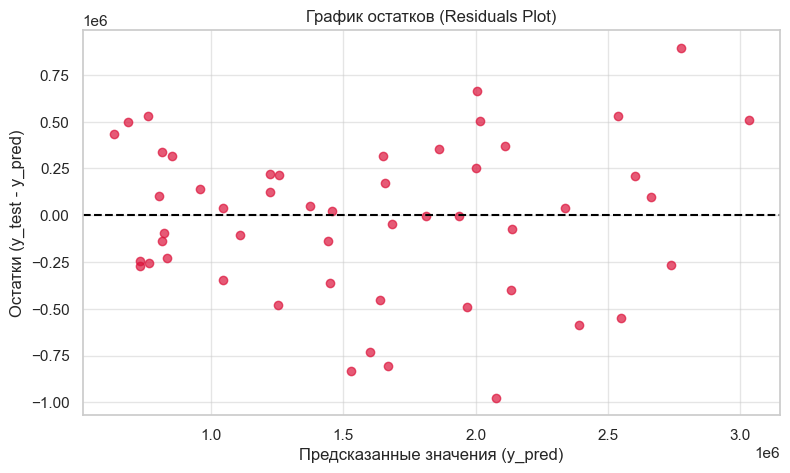

In [144]:
# 1. Считаем остатки
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))

# 2. Строим точечную диаграмму: по X — предсказания, по Y — ошибка
plt.scatter(y_pred, residuals, alpha=0.7, color='crimson')

# 3. Рисуем пунктирную линию идеального нуля
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.title('График остатков (Residuals Plot)')
plt.xlabel('Предсказанные значения (y_pred)')
plt.ylabel('Остатки (y_test - y_pred)')
plt.grid(True)
plt.show()

<div class="alert alert-info">
<b>Выводы по модели линейной регрессии:</b>

1. <b>Характер связи:</b> Между температурой воздуха (`Temperature`) и объемом потребления газа (`Sum`) наблюдается выраженная обратная линейная связь.
2. <b>Качество модели:</b>
   - Модель демонстрирует хороший коэффициент детерминации <b>R² = 0.729</b>, что означает, что 72.9% изменчивости потребления газа объясняются одной лишь температурой.
   - Средняя абсолютная ошибка <b>MAE ≈ 329,876</b> является адекватной относительно общего масштаба значений (миллионные объемы).
3. <b>Анализ остатков:</b> График остатков показывает хаотичное распределение точек относительно нулевой линии без явных закрученных паттернов, что подтверждает применимость линейной модели для данной задачи.
</div>